# WORC Datasets: Volume Density & Axis Extents Analysis

In [14]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import SimpleITK as sitk

In [15]:
DATA_DIR = Path("data/worc")

DATASETS = [
    "Lipo",
    "Desmoid",
    "Liver",
    "GIST",
    "CRLM",
    "Melanoma",
    "HeadAndNeck",
    "Glioma",
]


def compute_lesion_metrics(mask_path):
    img = sitk.ReadImage(str(mask_path))
    arr = sitk.GetArrayFromImage(img)
    spacing = img.GetSpacing()

    indices = np.argwhere(arr > 0)
    if indices.size == 0:
        return None

    z_pts, y_pts, x_pts = indices[:, 0], indices[:, 1], indices[:, 2]

    len_sagittal = (x_pts.max() - x_pts.min() + 1) * spacing[0]
    len_coronal = (y_pts.max() - y_pts.min() + 1) * spacing[1]
    len_axial = (z_pts.max() - z_pts.min() + 1) * spacing[2]

    voxel_vol = spacing[0] * spacing[1] * spacing[2]
    volume_cm3 = (len(indices) * voxel_vol) / 1000.0

    return {
        "volume_cm3": volume_cm3,
        "Sagittal": len_sagittal,
        "Coronal": len_coronal,
        "Axial": len_axial,
    }

In [16]:
records = []
for ds in DATASETS:
    ds_path = DATA_DIR / ds
    if not ds_path.exists():
        continue

    mask_files = list(ds_path.glob("**/mask*.nii*")) + list(
        ds_path.glob("**/segmentation*.nii*")
    )

    for mask_p in mask_files:
        metrics = compute_lesion_metrics(mask_p)
        if metrics:
            records.append({
                "dataset": ds,
                "patient_id": mask_p.parent.name,
                "file": mask_p.name,
                **metrics,
            })

df = pd.DataFrame(records)
df.head()

,dataset,patient_id,file,volume_cm3,Sagittal,Coronal,Axial
0,Lipo,Lipo-001,segmentation.nii.gz,186.866294,73.828125,49.921875,217.499972
1,Lipo,Lipo-002,segmentation.nii.gz,1223.064859,263.481006,224.886605,244.199944
2,Lipo,Lipo-003,segmentation.nii.gz,150.867500,70.729169,74.375002,99.000084
3,Lipo,Lipo-004,segmentation.nii.gz,662.856331,94.335938,274.218750,88.000000
4,Lipo,Lipo-005,segmentation.nii.gz,236.934976,119.703705,100.740741,126.720044


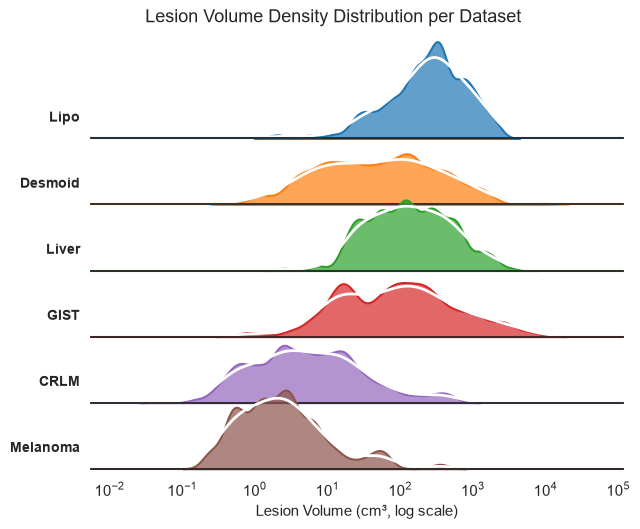

In [17]:
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

active_datasets = [d for d in DATASETS if d in df["dataset"].unique()]
palette = sns.color_palette("tab10", len(active_datasets))

g = sns.FacetGrid(
    df,
    row="dataset",
    hue="dataset",
    aspect=7,
    height=0.9,
    palette=palette,
    row_order=active_datasets,
)

g.map(
    sns.kdeplot,
    "volume_cm3",
    bw_adjust=0.5,
    clip_on=False,
    fill=True,
    alpha=0.7,
    linewidth=1.5,
    log_scale=True,
)
g.map(sns.kdeplot, "volume_cm3", clip_on=False, color="w", lw=2, log_scale=True)
g.map(plt.axhline, y=0, lw=1.5, clip_on=False)

for i, ax in enumerate(g.axes.flat):
    ax.text(
        -0.02,
        0.2,
        active_datasets[i],
        fontweight="bold",
        fontsize=10,
        transform=ax.transAxes,
        ha="right",
        va="center",
    )

g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=False, left=True)
g.set_xlabels("Lesion Volume (cm³, log scale)", fontsize=11)
plt.subplots_adjust(hspace=-0.35)
plt.suptitle("Lesion Volume Density Distribution per Dataset", fontsize=13, y=0.98)
plt.show()

C:\Users\lukin\AppData\Local\Temp\ipykernel_34140\3502207151.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g_violin = sns.catplot(


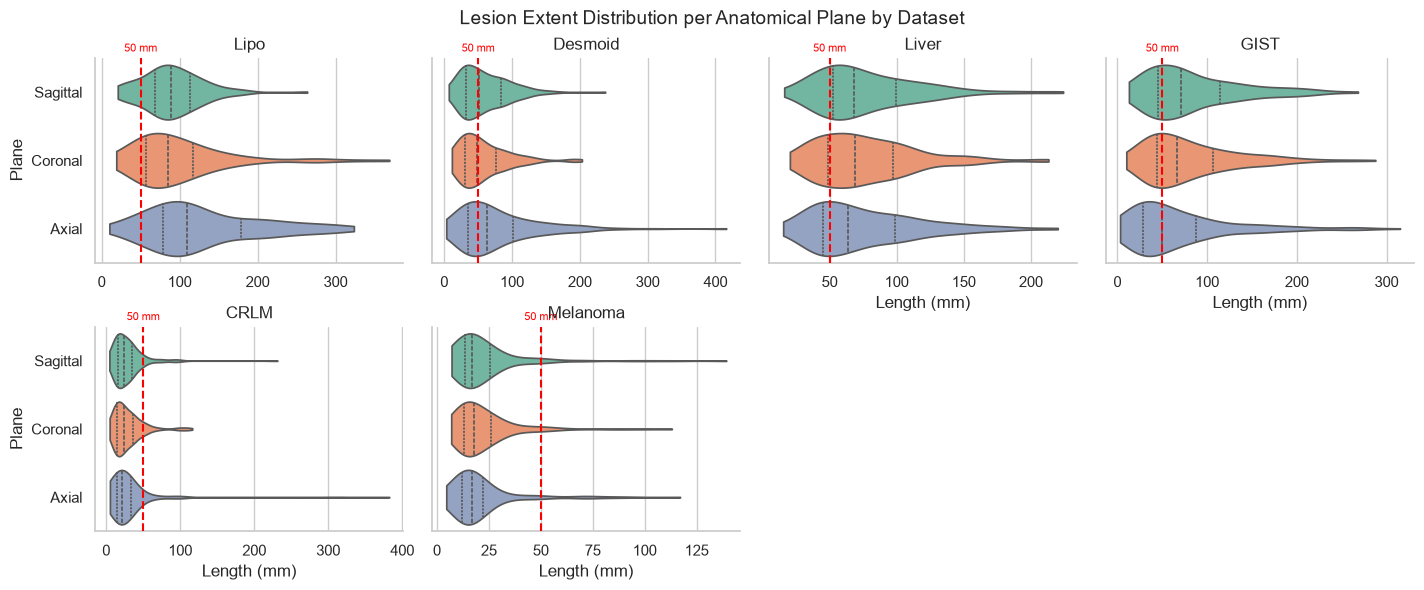

In [19]:
sns.set_theme(style="whitegrid")

df_planes = df.melt(
    id_vars=["dataset", "patient_id"],
    value_vars=["Sagittal", "Coronal", "Axial"],
    var_name="Plane",
    value_name="Length (mm)",
)

g_violin = sns.catplot(
    data=df_planes,
    x="Length (mm)",
    y="Plane",
    col="dataset",
    col_wrap=4,
    kind="violin",
    inner="quartile",
    cut=0,
    palette="Set2",
    height=3,
    aspect=1.2,
    sharex=False,
)

g_violin.set_titles(col_template="{col_name}")
for ax in g_violin.axes.flat:
    if ax is None:
        continue
    ax.axvline(50, color="red", linestyle="--", linewidth=1.5, zorder=5)
    ax.text(50, 1.02, "50 mm", color="red", fontsize=8, ha="center", va="bottom", transform=ax.get_xaxis_transform())
g_violin.fig.subplots_adjust(top=0.9)
g_violin.fig.suptitle(
    "Lesion Extent Distribution per Anatomical Plane by Dataset", fontsize=14
)
plt.show()
